In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('D:\\datafile\\spare_parts_expanded.csv')
df.head()

,spare_parts,quantity,costs,sale_price,date,total_revenue
0,Wheel,24,30,53,1 01 2020,"$1,272"
1,Tyre,20,80,110,2 01 2020,"$2,200"
2,Battery,46,85,95,3 01 2020,"$4,370"
3,Air Filter,37,36,48,4 01 2020,"$1,776"
4,Oil Filter,28,96,120,5 01 2020,"$3,360"


In [4]:
df[['date', 'total_revenue']].dtypes

date             object
total_revenue    object
dtype: object

In [5]:
df.isnull().sum()


spare_parts      0
quantity         0
costs            0
sale_price       0
date             0
total_revenue    0
dtype: int64

In [6]:
df['date'] = pd.to_datetime(df['date'])
df['date'].dtypes


dtype('<M8[ns]')

In [7]:
df.dtypes

spare_parts              object
quantity                  int64
costs                     int64
sale_price                int64
date             datetime64[ns]
total_revenue            object
dtype: object

In [8]:
df['total_revenue'] = df['total_revenue'].str.replace(',', '', regex = True)
df['total_revenue'] = df['total_revenue'].str.replace('$', '').astype(int)
df.head()

,spare_parts,quantity,costs,sale_price,date,total_revenue
0,Wheel,24,30,53,2020-01-01,1272
1,Tyre,20,80,110,2020-02-01,2200
2,Battery,46,85,95,2020-03-01,4370
3,Air Filter,37,36,48,2020-04-01,1776
4,Oil Filter,28,96,120,2020-05-01,3360


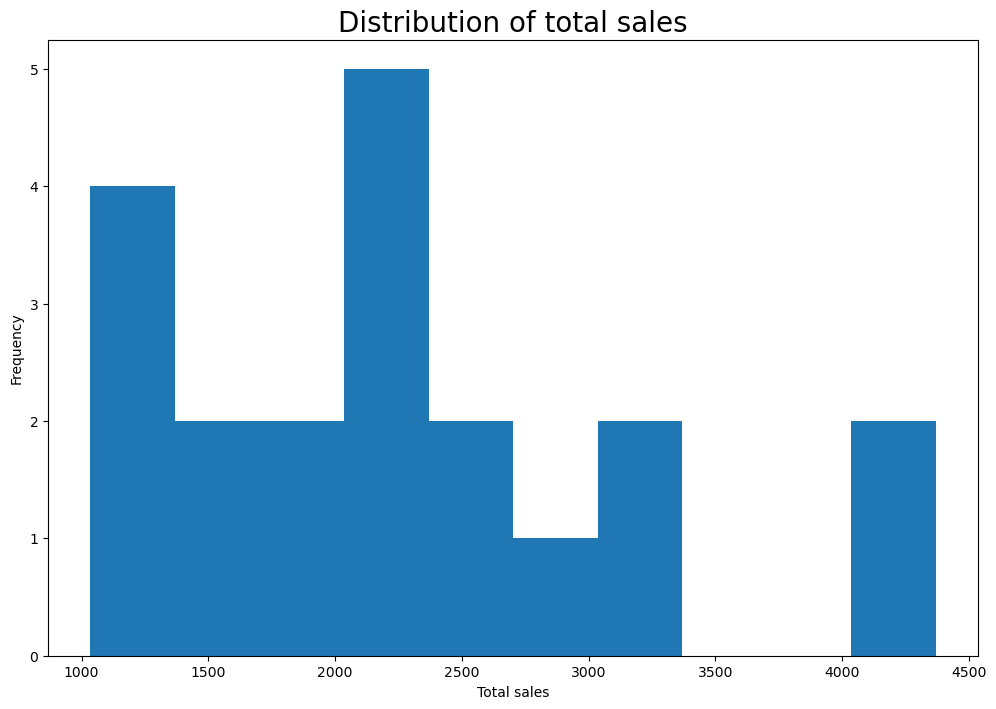

In [9]:
plt.figure(figsize = (12, 8))

plt.hist(df['total_revenue'], bins = 10)
plt.xlabel('Total sales')
plt.ylabel('Frequency')
plt.title('Distribution of total sales', fontsize = 20)
plt.show()

battery sales between 4000 and 5000 are outliers

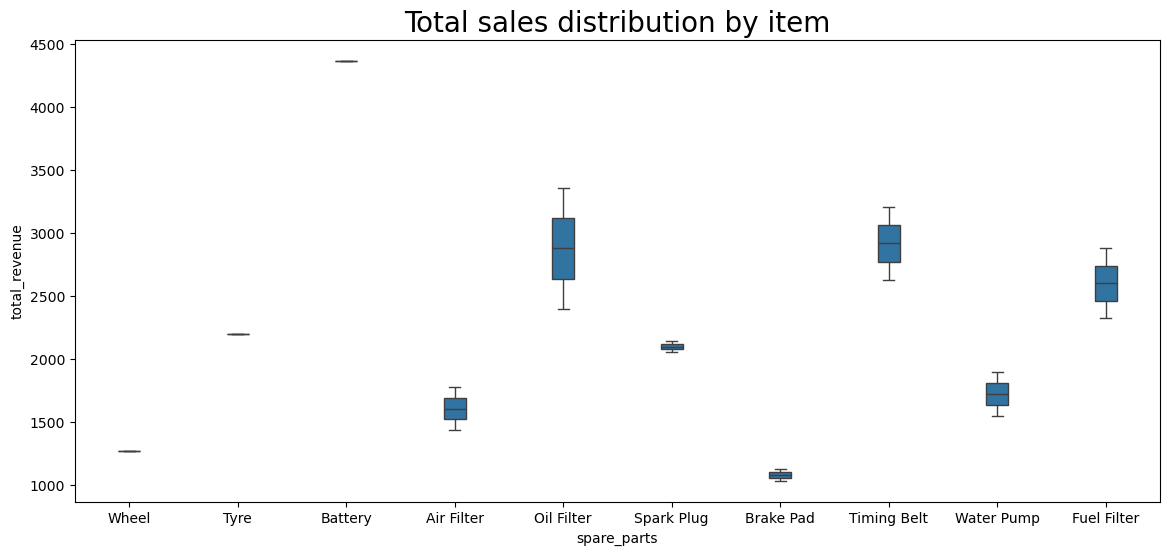

In [10]:
import seaborn as sns

plt.subplots(figsize = (14, 6))

sns.boxplot(x = 'spare_parts', y = 'total_revenue', data = df, width = 0.2, linewidth = 1.0)

plt.title('Total sales distribution by item', fontsize = 20)
plt.show()


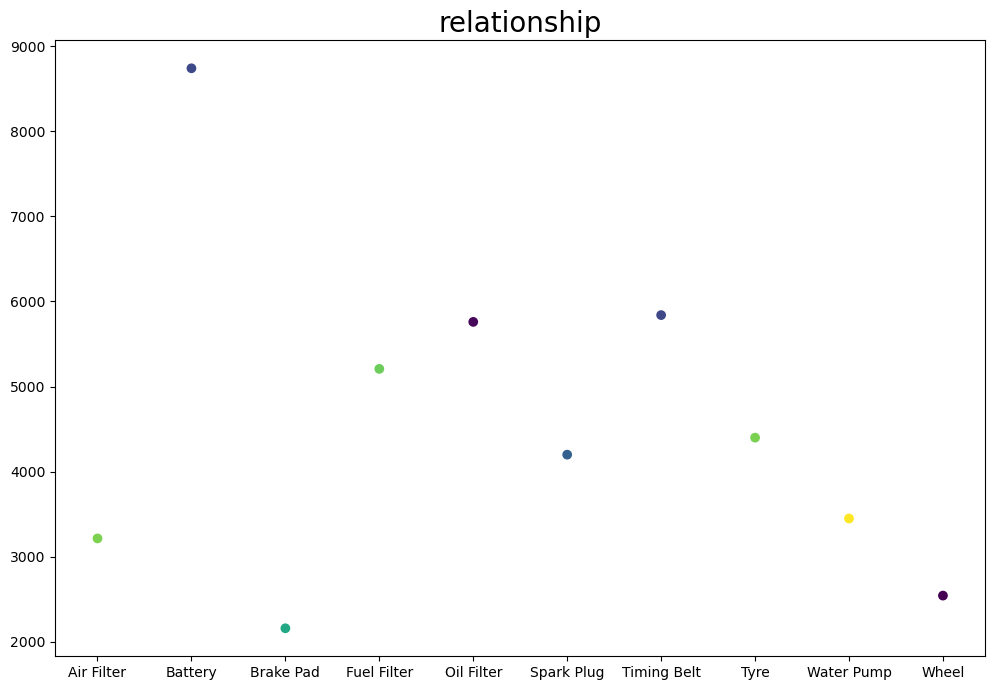

In [11]:
gp_sales = df.groupby('spare_parts')['total_revenue'].sum()


plt.figure(figsize = (12, 8))
colors = np.random.rand(10)
plt.scatter(gp_sales.index, gp_sales, c=colors, alpha = 1.0)
plt.title('relationship', fontsize = 20)
plt.show()

In [12]:
gp_sales.index

Index(['Air Filter', 'Battery', 'Brake Pad', 'Fuel Filter', 'Oil Filter',
       'Spark Plug', 'Timing Belt', 'Tyre', 'Water Pump', 'Wheel'],
      dtype='object', name='spare_parts')

In [13]:
gp_sales

spare_parts
Air Filter     3216
Battery        8740
Brake Pad      2160
Fuel Filter    5208
Oil Filter     5760
Spark Plug     4200
Timing Belt    5840
Tyre           4400
Water Pump     3450
Wheel          2544
Name: total_revenue, dtype: int64

In [14]:
df2 = df.select_dtypes(include = 'int')
df2.head()

,quantity,costs,sale_price,total_revenue
0,24,30,53,1272
1,20,80,110,2200
2,46,85,95,4370
3,37,36,48,1776
4,28,96,120,3360


In [15]:
df.head()

,spare_parts,quantity,costs,sale_price,date,total_revenue
0,Wheel,24,30,53,2020-01-01,1272
1,Tyre,20,80,110,2020-02-01,2200
2,Battery,46,85,95,2020-03-01,4370
3,Air Filter,37,36,48,2020-04-01,1776
4,Oil Filter,28,96,120,2020-05-01,3360


In [16]:
df['total cost'] = df['costs'] * df['quantity']
df.head()

,spare_parts,quantity,costs,sale_price,date,total_revenue,total cost
0,Wheel,24,30,53,2020-01-01,1272,720
1,Tyre,20,80,110,2020-02-01,2200,1600
2,Battery,46,85,95,2020-03-01,4370,3910
3,Air Filter,37,36,48,2020-04-01,1776,1332
4,Oil Filter,28,96,120,2020-05-01,3360,2688


In [17]:
df['profit'] =  df['total_revenue'] - df['total cost'] 
df.head()

,spare_parts,quantity,costs,sale_price,date,total_revenue,total cost,profit
0,Wheel,24,30,53,2020-01-01,1272,720,552
1,Tyre,20,80,110,2020-02-01,2200,1600,600
2,Battery,46,85,95,2020-03-01,4370,3910,460
3,Air Filter,37,36,48,2020-04-01,1776,1332,444
4,Oil Filter,28,96,120,2020-05-01,3360,2688,672


In [18]:
df

,spare_parts,quantity,costs,sale_price,date,total_revenue,total cost,profit
0,Wheel,24,30,53,2020-01-01,1272,720,552
1,Tyre,20,80,110,2020-02-01,2200,1600,600
2,Battery,46,85,95,2020-03-01,4370,3910,460
3,Air Filter,37,36,48,2020-04-01,1776,1332,444
4,Oil Filter,28,96,120,2020-05-01,3360,2688,672
5,Spark Plug,49,20,42,2020-06-01,2058,980,1078
6,Brake Pad,23,28,45,2020-07-01,1035,644,391
7,Timing Belt,22,87,146,2020-08-01,3212,1914,1298
8,Water Pump,38,31,50,2020-09-01,1900,1178,722
9,Fuel Filter,31,56,93,2020-10-01,2883,1736,1147


In [19]:
df_group = df.groupby('spare_parts')[['profit']].sum()
df_group

,profit
spare_parts,
Air Filter,804
Battery,920
Brake Pad,816
Fuel Filter,2072
Oil Filter,1152
Spark Plug,2200
Timing Belt,2360
Tyre,1200
Water Pump,1311


In [20]:
most_profitable = df_group['profit'].idxmax()
least_profitable = df_group['profit'].min()
least_profitable

804

In [21]:
total = df_group['profit'].sum()
total

np.int64(13939)

In [22]:
percentage_drop = (least_profitable/total)*100
percentage_drop.round(2)

np.float64(5.77)

In [23]:
df.head()

,spare_parts,quantity,costs,sale_price,date,total_revenue,total cost,profit
0,Wheel,24,30,53,2020-01-01,1272,720,552
1,Tyre,20,80,110,2020-02-01,2200,1600,600
2,Battery,46,85,95,2020-03-01,4370,3910,460
3,Air Filter,37,36,48,2020-04-01,1776,1332,444
4,Oil Filter,28,96,120,2020-05-01,3360,2688,672


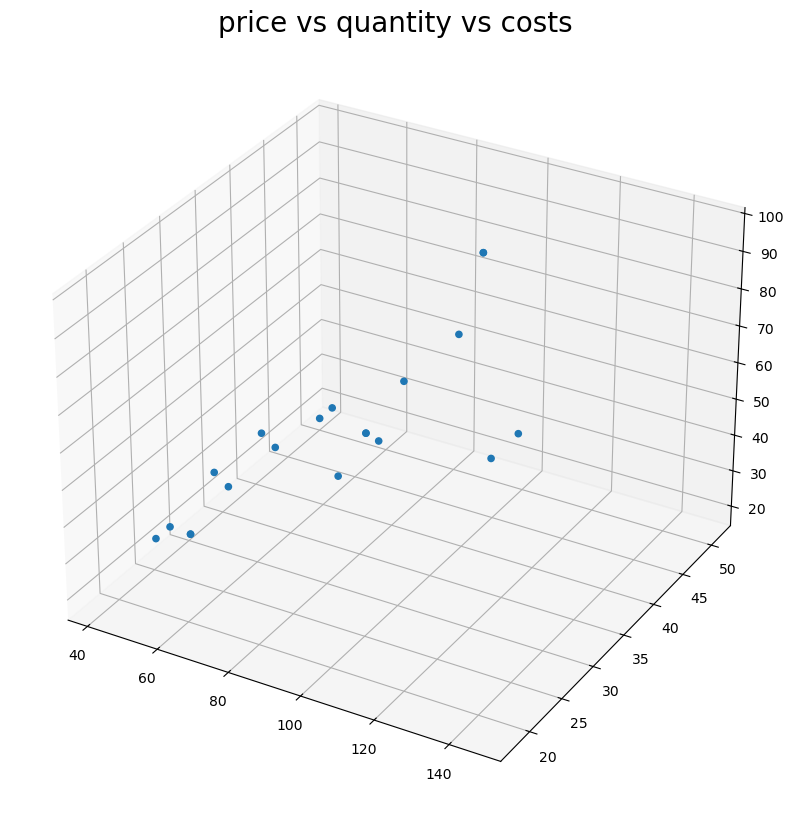

In [24]:
fig = plt.figure(figsize=(15, 10))

ax = fig.add_subplot(111, projection = '3d') 

ax.scatter(df['sale_price'],df['quantity'],df['costs'], alpha = 1.0)


plt.title('price vs quantity vs costs', fontsize = 20)
plt.show()



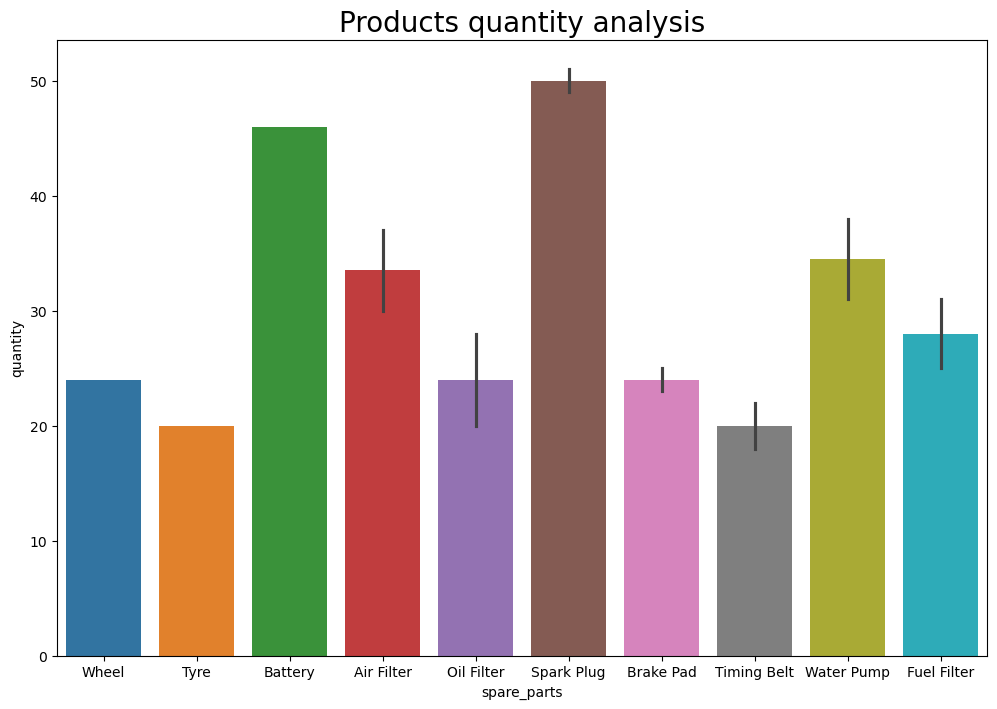

In [26]:
import seaborn as sns


plt.figure(figsize =(12, 8))

sns.barplot(x = 'spare_parts', y = 'quantity', hue = 'spare_parts', data = df)
plt.title('Products quantity analysis', fontsize = 20)
plt.show()




In [27]:
df.dtypes

spare_parts              object
quantity                  int64
costs                     int64
sale_price                int64
date             datetime64[ns]
total_revenue             int64
total cost                int64
profit                    int64
dtype: object

In [28]:
df_group = df.groupby('date')['total_revenue'].sum()
df_group

date
2020-01-01     1272
2020-02-01     4400
2020-03-01    10012
2020-04-01     3216
2020-05-01     5760
2020-06-01     4200
2020-07-01     2160
2020-08-01     5840
2020-09-01     3450
2020-10-01     2883
2020-11-01     2325
Name: total_revenue, dtype: int64

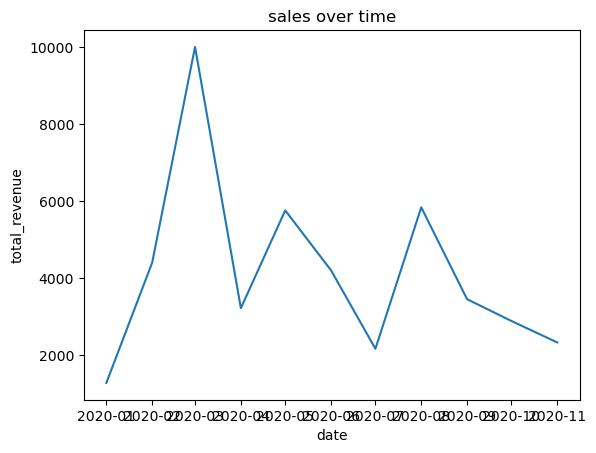

In [31]:
import seaborn as sns

sns.lineplot(x = df_group.index, y=df_group)
plt.title('sales over time')
plt.show()